In [1]:
# import necessary modules
# uncomment to get plots displayed in notebook
%matplotlib inline


### import class wrapper

from classy import Class

### math stuff
import numpy as np
from scipy.optimize import fsolve

### Controlling iteration speed

from tqdm.notebook import trange, tqdm 

### plotting stuff
import matplotlib.pyplot as plt
#import matplotlib.ticker as mticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import cmasher as cmr
import matplotlib.patheffects as pe
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.ticker import FixedLocator, FixedFormatter
from scipy.interpolate import interp1d
from matplotlib.lines import Line2D
#import pandas as pd 

import itertools



In [2]:
### INPUT ###
Omega_scf=1e-4 #scalar field density parameter at present, can be whatever as it's recomputed anyway, but needs to be sth for CLASS to realize there's scalar field.
k_values = [1e-3, 1e-2, 1e-1, 1]
k_values_CLASS = ', '.join([str(k) for k in k_values])
###
common_settings = {
                    'output': 'tCl,pCl,lCl,mPk',
                    'k_output_values': k_values_CLASS,
                    'lensing': 'yes',
                    #'temperature_contributions': 'tsw', 
                    'P_k_max_h/Mpc': 10, 
                    # LambdaCDM parameters
                   'h': 0.67810,
                   'omega_b': 0.02238280 ,
                   'Omega_chi': 0.27, # this is the dark matter density parameter
                   'Omega_cdm': 1e-5,
                   'Omega_Lambda': 0.70,
                   'Omega_k': 0,
                   #'gauge': 'new', 
                   ### let's add some massive neutrinos
                #    'N_ur': 0,
                #    'N_ncdm': 1, 
                #    'deg_ncdm': 3,
                #    'm_ncdm': 0.02, #eV
                #     'T_ncdm': 0.71611,
                   }  

no_scalar = { 
                  'output': 'tCl,pCl,lCl,mPk',
                  'k_output_values': k_values_CLASS,
                  'lensing': 'yes',
                  #'temperature_contributions': 'tsw',
                  'P_k_max_h/Mpc': 10, 
                  # LambdaCDM parameters
                  'h': 0.67810,
                  'omega_b': 0.02238280,
                  'Omega_cdm': 0.27,
                  #'Omega_Lambda': 0.7,
                  # 'Omega_k': 0.,
                  # 'Omega_scf': 0.,
                  # 'Omega_fld': 0., 
                  #'gauge': 'sync', 
                  #'beta': 0.0, 
                   }  

In [3]:
### Run CLASS ###
ScalarCLASS = {}
beta_lrm = [0.0, 0.005, 0.02]
temp_contributions = {
                      'SW': 'tsw',
                      'ISW': 'eisw, lisw',
                      'SW+ISW': 'tsw, eisw, lisw',
                      'SW+ISW+Doppler': 'tsw, eisw, lisw, dop',
                      'Doppler': 'dop',
                      'SW+Doppler': 'tsw, dop',
                      'SW+Doppler+ISW': 'tsw, eisw, lisw, dop',
                      'Polarization': 'pol',
                      'full': 'tsw, eisw, lisw, dop, pol',
                      }
s_ini_factor = [0, 1e2, 1e4, 1e6, 1e8]
s_ini = 1e-4
gauge = 'new'
for beta, temp_contribution in itertools.product(beta_lrm, temp_contributions.values()):
    if beta != 0.0:
        phi_prime_ini = 1 # WIP, just a rescaling of actual initial value
    else:
        phi_prime_ini = 0.0
    #print(f'Running CLASS for beta = {beta} and phi_ini = {np.sqrt(beta/2)**(-1)*s_ini}, phi_prime_ini = {phi_prime_ini}') 
    ScalarCLASS[beta, temp_contribution] = Class()
    ScalarCLASS[beta, temp_contribution].set(common_settings)
    #print(f'Using temperature contributions: {temp_contribution}')
    ScalarCLASS[beta, temp_contribution].set({
                    'temperature_contributions': temp_contribution,
                    'early_late_isw_redshift' : 30,
                    'gauge': gauge,
                    'scf_parameters': f'0.0, 0.1, 0.0, 0.0, {s_ini}, {phi_prime_ini}',
                    'attractor_ic_scf': 'no',
                    'beta': beta,
                    'Omega_scf': Omega_scf,
                    })
    ScalarCLASS[beta, temp_contribution].compute()
    
print(ScalarCLASS.keys())
    
# Initialize dictionaries for background and perturbation quantities
bgScalar, pbScalar = {}, {}
z, a, H = {}, {}, {}
phi_scf, dphi_scf, V_scf = {}, {}, {}
delta_chi, delta_cdm, theta_cdm, delta_g, delta_scf, delta_b = {}, {}, {}, {}, {}, {}
delta_m = {}
#theta_cdm, psi, phi = {}, {}, {}
rho_g, rho_cdm, rho_b, rho_ur, rho_scf, rho_lambda, rho_chi = {}, {}, {}, {}, {}, {}, {}
rho_ncdm = {}
frac_chi = {}
rho_tot, rho_crit = {}, {}
p_scf, comov = {}, {}
# Initialize dictionaries for power spectrum
ll, clTT, clEE, clTE, clPP = {}, {}, {}, {}, {}
psi, phi = {}, {}

# Loop over each beta value and extract necessary background and perturbation data
for beta, temp_contribution in itertools.product(beta_lrm, temp_contributions.values()):
    #print(f'Extracting data for gauge = {gauge}, beta = {beta}')
    ### BACKGROUND
    bgScalar = ScalarCLASS[beta, temp_contribution].get_background()
    thScalar = ScalarCLASS[beta, temp_contribution].get_thermodynamics()

    # Extract some background cosmological quantities
    H[beta, temp_contribution] = bgScalar['H [1/Mpc]']
    z[beta, temp_contribution] = bgScalar['z']
    comov[beta, temp_contribution] = bgScalar['comov. dist.']

    # Extract energy densities for non-scalar components
    rho_g[beta, temp_contribution] = bgScalar['(.)rho_g']
    rho_b[beta, temp_contribution] = bgScalar['(.)rho_b']
    rho_chi[beta, temp_contribution] = bgScalar['(.)rho_chi']
    rho_cdm[beta, temp_contribution] = bgScalar['(.)rho_cdm']
    
    frac_chi[beta, temp_contribution] = rho_chi[beta, temp_contribution] / (rho_chi[beta, temp_contribution] + rho_b[beta, temp_contribution])
    
    rho_lambda[beta, temp_contribution] = bgScalar['(.)rho_lambda']
    rho_ur[beta, temp_contribution] = bgScalar['(.)rho_ur']
    rho_tot[beta, temp_contribution] = bgScalar['(.)rho_tot']
    rho_crit[beta, temp_contribution] = bgScalar['(.)rho_crit']
    
    # Extract scalar field quantities
    phi_scf[beta, temp_contribution] = bgScalar['phi_scf']
    dphi_scf[beta, temp_contribution] = bgScalar["phi'_scf"]
    V_scf[beta, temp_contribution] = bgScalar['V_scf']
    rho_scf[beta, temp_contribution] = bgScalar['(.)rho_scf']
    p_scf[beta, temp_contribution] = bgScalar['(.)p_scf']
    
    ### PERTURBATIONS
    pbScalar = ScalarCLASS[beta, temp_contribution].get_perturbations()
    for i in range(len(k_values)):
        scalar_data = pbScalar['scalar'][i]  # Scalar perturbations for selected k-values
        #print(scalar_data.keys())
        a[temp_contribution, beta, k_values[i]] = scalar_data['a']
        
        # Extract perturbation quantities
        delta_cdm[temp_contribution, beta, k_values[i]] = scalar_data['delta_cdm']
        delta_chi[temp_contribution, beta, k_values[i]] = scalar_data['delta_chi']
        delta_g[temp_contribution, beta, k_values[i]] = scalar_data['delta_g']
        delta_scf[temp_contribution, beta, k_values[i]] = scalar_data['delta_scf']
        delta_b[temp_contribution, beta, k_values[i]] = scalar_data['delta_b']
        frac_chi_interp = np.interp(a[temp_contribution, beta, k_values[i]], 1/(1+z[beta, temp_contribution]), frac_chi[beta, temp_contribution])
        delta_m[temp_contribution, beta, k_values[i]] = frac_chi_interp*delta_cdm[temp_contribution, beta, k_values[i]] + (1-frac_chi_interp)*delta_b[temp_contribution, beta, k_values[i]]
        theta_cdm[temp_contribution, beta, k_values[i]] = scalar_data['theta_cdm']
        psi[beta, temp_contribution] = scalar_data['psi']
        phi[beta, temp_contribution] = scalar_data['phi']
        
    ### POWER SPECTRUM
    
    clScalar = ScalarCLASS[beta, temp_contribution].lensed_cl(2500)
    ll[beta, temp_contribution] = clScalar['ell'][2:]
    clTT[beta, temp_contribution] = clScalar['tt'][2:]
    clEE[beta, temp_contribution] = clScalar['ee'][2:]
    clTE[beta, temp_contribution] = clScalar['te'][2:]
    clPP[beta, temp_contribution] = clScalar['pp'][2:]
        


[Iter 0] Omega0_lambda = 6.812216887286865e-01 (change = 1.681e+00)
[Iter 0] Omega0_lambda = 6.812216887286865e-01 (change = 1.681e+00)
[Iter 0] Omega0_lambda = 6.812216887286865e-01 (change = 1.681e+00)
[Iter 0] Omega0_lambda = 6.812216887286865e-01 (change = 1.681e+00)
[Iter 0] Omega0_lambda = 6.812216887286865e-01 (change = 1.681e+00)
[Iter 0] Omega0_lambda = 6.812216887286865e-01 (change = 1.681e+00)
[Iter 0] Omega0_lambda = 6.812216887286865e-01 (change = 1.681e+00)
[Iter 0] Omega0_lambda = 6.812216887286865e-01 (change = 1.681e+00)
[Iter 0] Omega0_lambda = 6.812216887286865e-01 (change = 1.681e+00)
[Iter 0] Omega0_lambda = 6.892024029424242e-01 (change = 1.689e+00)
[Iter 0] Omega0_lambda = 6.892024029424242e-01 (change = 1.689e+00)
[Iter 0] Omega0_lambda = 6.892024029424242e-01 (change = 1.689e+00)
[Iter 0] Omega0_lambda = 6.892024029424242e-01 (change = 1.689e+00)
[Iter 0] Omega0_lambda = 6.892024029424242e-01 (change = 1.689e+00)
[Iter 0] Omega0_lambda = 6.892024029424242e-01 (

In [4]:
LCDM = {}
bgLCDM, pbLCDM = {}, {}
z_lcdm, H_lcdm = {}, {}
rho_cdm_lcdm, rho_b_lcdm, rho_g_lcdm, rho_lambda_lcdm, rho_ur_lcdm = {}, {}, {}, {}, {}
#rho_k_lcdm = {}
comov_lcdm = {}
frac_cdm = {}
frac_cdm_interp = {}
rho_tot_lcdm, rho_crit_lcdm = {}, {}
ll_lcdm, clTT_lcdm, clEE_lcdm, clTE_lcdm, clPP_lcdm = {}, {}, {}, {}, {}
delta_cdm_lcdm, delta_b_lcdm, theta_cdm_lcdm, delta_g_lcdm, a_lcdm = {}, {}, {}, {}, {}
delta_m_lcdm = {}

for temp_contribution in temp_contributions.values():
    LCDM[temp_contribution] = Class()
    LCDM[temp_contribution].set(no_scalar)
    LCDM[temp_contribution].set({
                    'gauge': gauge,
                    'temperature_contributions': temp_contribution,
                    'beta': 0.0,  # No long-range modification in LCDM
                    })
    LCDM[temp_contribution].compute()

    # Load LCDM background and perturbation data
    bgLCDM[temp_contribution] = LCDM[temp_contribution].get_background()
    pbLCDM[temp_contribution] = LCDM[temp_contribution].get_perturbations()

    # Extract LCDM background and perturbation quantities
    z_lcdm[temp_contribution] = bgLCDM[temp_contribution]['z']
    H_lcdm[temp_contribution] = bgLCDM[temp_contribution]['H [1/Mpc]']
    rho_cdm_lcdm[temp_contribution] = bgLCDM[temp_contribution]['(.)rho_cdm']
    rho_b_lcdm[temp_contribution] = bgLCDM[temp_contribution]['(.)rho_b']
    rho_g_lcdm[temp_contribution] = bgLCDM[temp_contribution]['(.)rho_g']
    rho_lambda_lcdm[temp_contribution] = bgLCDM[temp_contribution]['(.)rho_lambda']
    rho_ur_lcdm[temp_contribution] = bgLCDM[temp_contribution]['(.)rho_ur']
    #rho_k_lcdm = bgLCDM['(.)rho_scf']
    comov_lcdm[temp_contribution] = bgLCDM[temp_contribution]['comov. dist.']

    frac_cdm[temp_contribution] = rho_cdm_lcdm[temp_contribution]/(rho_cdm_lcdm[temp_contribution] + rho_b_lcdm[temp_contribution])

    for i in range(len(k_values)):
        scalar_data = pbLCDM[temp_contribution]['scalar'][i]  # Scalar perturbations for selected k-values
        # Extract perturbation quantities
        a_lcdm[temp_contribution, k_values[i]] = scalar_data['a']
        delta_cdm_lcdm[temp_contribution, k_values[i]] = scalar_data['delta_cdm']
        theta_cdm_lcdm[temp_contribution, k_values[i]] = scalar_data['theta_cdm']
        delta_b_lcdm[temp_contribution, k_values[i]] = scalar_data['delta_b']
        
        frac_cdm_interp[temp_contribution] = np.interp(a_lcdm[temp_contribution, k_values[i]], 1/(1+z_lcdm[temp_contribution]), frac_cdm[temp_contribution])
        delta_m_lcdm[temp_contribution, k_values[i]] = frac_cdm_interp[temp_contribution] * delta_cdm_lcdm[temp_contribution, k_values[i]] + (1-frac_cdm_interp[temp_contribution]) * delta_b_lcdm[temp_contribution, k_values[i]]
        
        delta_g_lcdm[temp_contribution, k_values[i]] = scalar_data['delta_g']
        
    clLCDM = LCDM[temp_contribution].lensed_cl(2500)
    ll_lcdm[temp_contribution] = clLCDM['ell'][2:]
    clTT_lcdm[temp_contribution] = clLCDM['tt'][2:]
    clEE_lcdm[temp_contribution] = clLCDM['ee'][2:]
    clTE_lcdm[temp_contribution] = clLCDM['te'][2:]
    clPP_lcdm[temp_contribution] = clLCDM['pp'][2:]
        
    rho_tot_lcdm[temp_contribution] = bgLCDM[temp_contribution]['(.)rho_tot']
    rho_crit_lcdm[temp_contribution] = bgLCDM[temp_contribution]['(.)rho_crit']
    
    print(a_lcdm.keys())


dict_keys([('tsw', 0.001), ('tsw', 0.01), ('tsw', 0.1), ('tsw', 1)])
dict_keys([('tsw', 0.001), ('tsw', 0.01), ('tsw', 0.1), ('tsw', 1), ('eisw, lisw', 0.001), ('eisw, lisw', 0.01), ('eisw, lisw', 0.1), ('eisw, lisw', 1)])
dict_keys([('tsw', 0.001), ('tsw', 0.01), ('tsw', 0.1), ('tsw', 1), ('eisw, lisw', 0.001), ('eisw, lisw', 0.01), ('eisw, lisw', 0.1), ('eisw, lisw', 1), ('tsw, eisw, lisw', 0.001), ('tsw, eisw, lisw', 0.01), ('tsw, eisw, lisw', 0.1), ('tsw, eisw, lisw', 1)])
dict_keys([('tsw', 0.001), ('tsw', 0.01), ('tsw', 0.1), ('tsw', 1), ('eisw, lisw', 0.001), ('eisw, lisw', 0.01), ('eisw, lisw', 0.1), ('eisw, lisw', 1), ('tsw, eisw, lisw', 0.001), ('tsw, eisw, lisw', 0.01), ('tsw, eisw, lisw', 0.1), ('tsw, eisw, lisw', 1), ('tsw, eisw, lisw, dop', 0.001), ('tsw, eisw, lisw, dop', 0.01), ('tsw, eisw, lisw, dop', 0.1), ('tsw, eisw, lisw, dop', 1)])
dict_keys([('tsw', 0.001), ('tsw', 0.01), ('tsw', 0.1), ('tsw', 1), ('eisw, lisw', 0.001), ('eisw, lisw', 0.01), ('eisw, lisw', 0.1), 

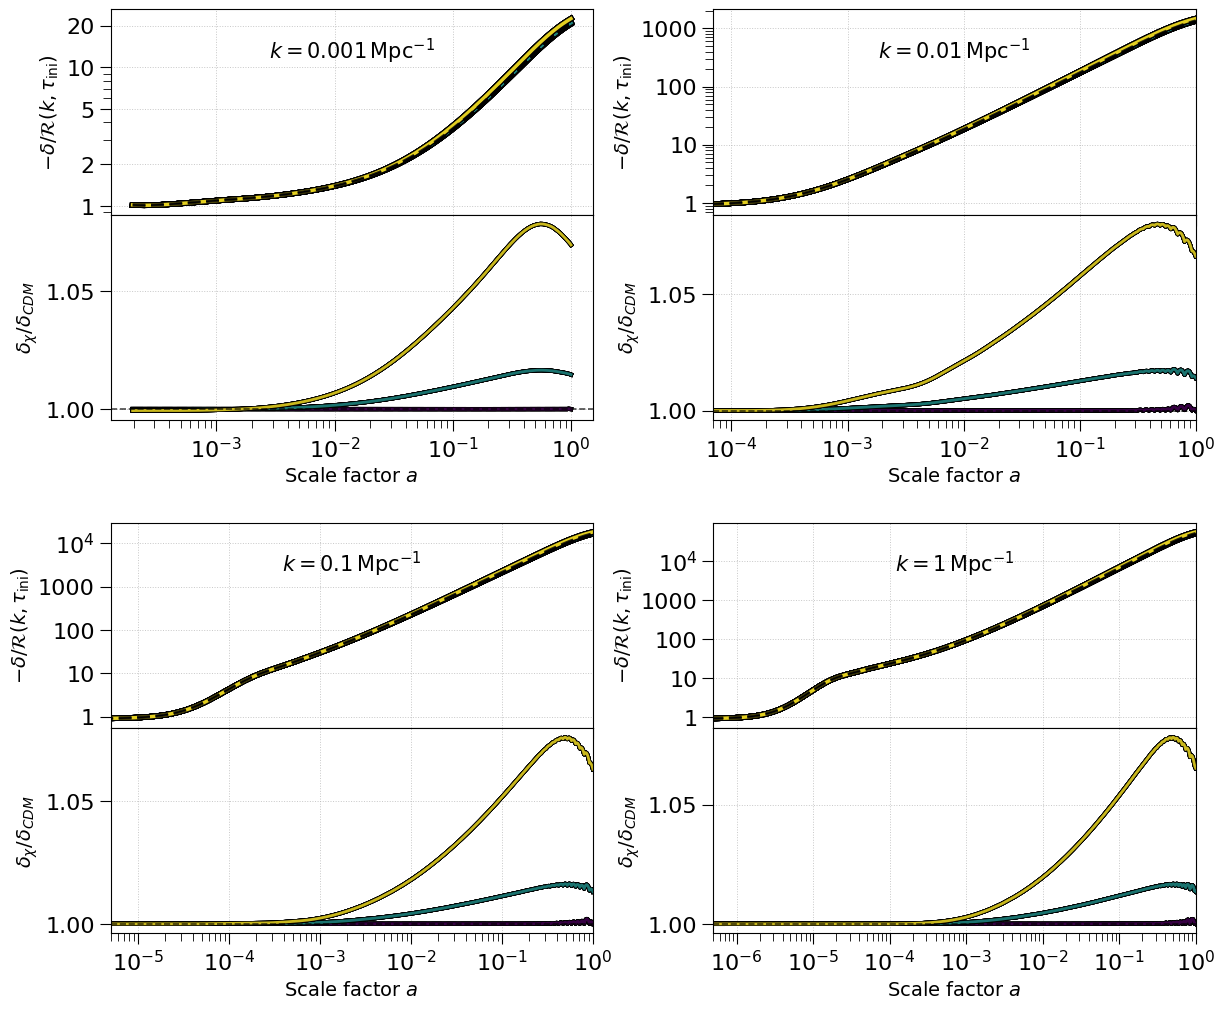

In [5]:
ks = k_values

fig = plt.figure(figsize=(14, 12))
outer = GridSpec(2, 2, wspace=0.25, hspace=0.25)

# Assign a unique color to each beta
beta_colors = {beta: color for beta, color in zip(beta_lrm, plt.cm.viridis(np.linspace(0, 1, len(beta_lrm))))}

for idx, k in enumerate(ks):
    row, col = divmod(idx, 2)
    inner = GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[idx], height_ratios=[2, 2], hspace=0.0)

    ax1 = fig.add_subplot(inner[0])
    ax2 = fig.add_subplot(inner[1], sharex=ax1)

    # Interpolation function for LCDM
    interp_lcdm = {
        temp_contribution: interp1d(a_lcdm[temp_contribution, k], delta_cdm_lcdm[temp_contribution, k], kind='linear',
                        bounds_error=False, fill_value='extrapolate')
        for temp_contribution in temp_contributions.values()
    }

    beta_legend_shown = set()

    for beta, temp_contribution in itertools.product(beta_lrm, temp_contributions.values()):
            linestyle = '--' if temp_contribution == 'tsw' else '-'
            color = beta_colors[beta]

            # Plot delta_chi
            label = rf'$\beta = {beta}$' if beta not in beta_legend_shown else None
            ax1.loglog(a[temp_contribution, beta, k], -delta_chi[temp_contribution, beta, k],
                    label=label,
                    linewidth=2.5, path_effects=[pe.withStroke(linewidth=4, foreground='black')],
                    alpha=0.9, linestyle=linestyle, color=color)

            # Interpolate and plot LCDM
            delta_lcdm_interp = interp_lcdm[temp_contribution](a[temp_contribution, beta, k])
            ratio = delta_cdm[temp_contribution, beta, k] / delta_lcdm_interp

            ax2.semilogx(a[temp_contribution, beta, k], ratio,
                        linewidth=2.0, path_effects=[pe.withStroke(linewidth=3, foreground='black')],
                        alpha=0.8, linestyle=linestyle, color=color)

            if beta not in beta_legend_shown:
                beta_legend_shown.add(beta)

            # LCDM reference line
            ax1.loglog(a[temp_contribution, beta, k], -delta_lcdm_interp,
                    linewidth=2.5, linestyle='--', alpha=0.8, color='black',
                    path_effects=[pe.withStroke(linewidth=1, foreground='black')])

    ax2.axhline(1, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
    ax1.grid(which='major', linestyle=':', linewidth=0.7, alpha=0.7)
    ax2.grid(which='major', linestyle=':', linewidth=0.7, alpha=0.7)

    if idx == 0:
        ax1.yaxis.set_major_locator(FixedLocator((1.0, 2.0, 5.0, 10, 20)))
        ax1.yaxis.set_major_formatter(FixedFormatter(['1', '2', '5', '10', '20']))
    if idx == 1:
        ax2.set_xlim(7e-5, 1)
        ax1.yaxis.set_major_locator(FixedLocator((1.0, 10.0, 100.0, 1000)))
        ax1.yaxis.set_major_formatter(FixedFormatter(['1', '10', '100', '1000']))
    if idx == 2:
        ax2.set_xlim(5e-6, 1)
        ax1.yaxis.set_major_locator(FixedLocator((1.0, 10.0, 100.0, 1000, 10000)))
        ax1.yaxis.set_major_formatter(FixedFormatter(['1', '10', '100', '1000', r'$10^4$']))
    if idx == 3:
        ax2.set_xlim(5e-7, 1)
        ax1.yaxis.set_major_locator(FixedLocator((1.0, 10.0, 100.0, 1000, 10000)))
        ax1.yaxis.set_major_formatter(FixedFormatter(['1', '10', '100', '1000', r'$10^4$']))

    ax1.tick_params(axis='x', which='both', labelbottom=False)
    ax1.tick_params(axis='both', which='major', labelsize=16, length=8)
    ax2.tick_params(axis='both', which='major', labelsize=16, length=8)
    ax1.tick_params(axis='both', which='minor', labelsize=16, length=6)
    ax2.tick_params(axis='both', which='minor', labelsize=16, length=6)
    ax2.yaxis.set_major_locator(FixedLocator((1.0, 1.05, 1.1, 1.15)))

    ax2.set_xlabel(r'Scale factor $a$', fontsize=14)
    ax1.set_ylabel(r'$-\delta/\mathcal{R}(k, \tau_\mathrm{ini})$', fontsize=14)
    ax2.set_ylabel(r'$\delta_\chi/\delta_{CDM}$', fontsize=14)

    ax1.text(0.5, 0.8, rf'$k = {k}\,\mathrm{{Mpc}}^{{-1}}$', fontsize=15,
             ha='center', va='center', transform=ax1.transAxes)

# Shared legend (colors for beta only)
handles, labels = ax1.get_legend_handles_labels()
# Custom legend handles for gauges
gauge_handles = [
    Line2D([0], [0], color='black', linestyle='-', linewidth=2.5, label='Newtonian gauge'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2.5, label='Synchronous gauge')
]

# Combine beta and gauge legend entries
# all_handles = handles + gauge_handles
# all_labels = labels + ['Newtonian gauge', 'Synchronous gauge']

# fig.legend(all_handles, all_labels, loc='upper center', fontsize=14,
#            ncol=len(beta_lrm) + 2, frameon=False)

#plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('delta_cdm_2x2_diff_k_temp_contributions.pdf', dpi=300, bbox_inches='tight')
plt.show()


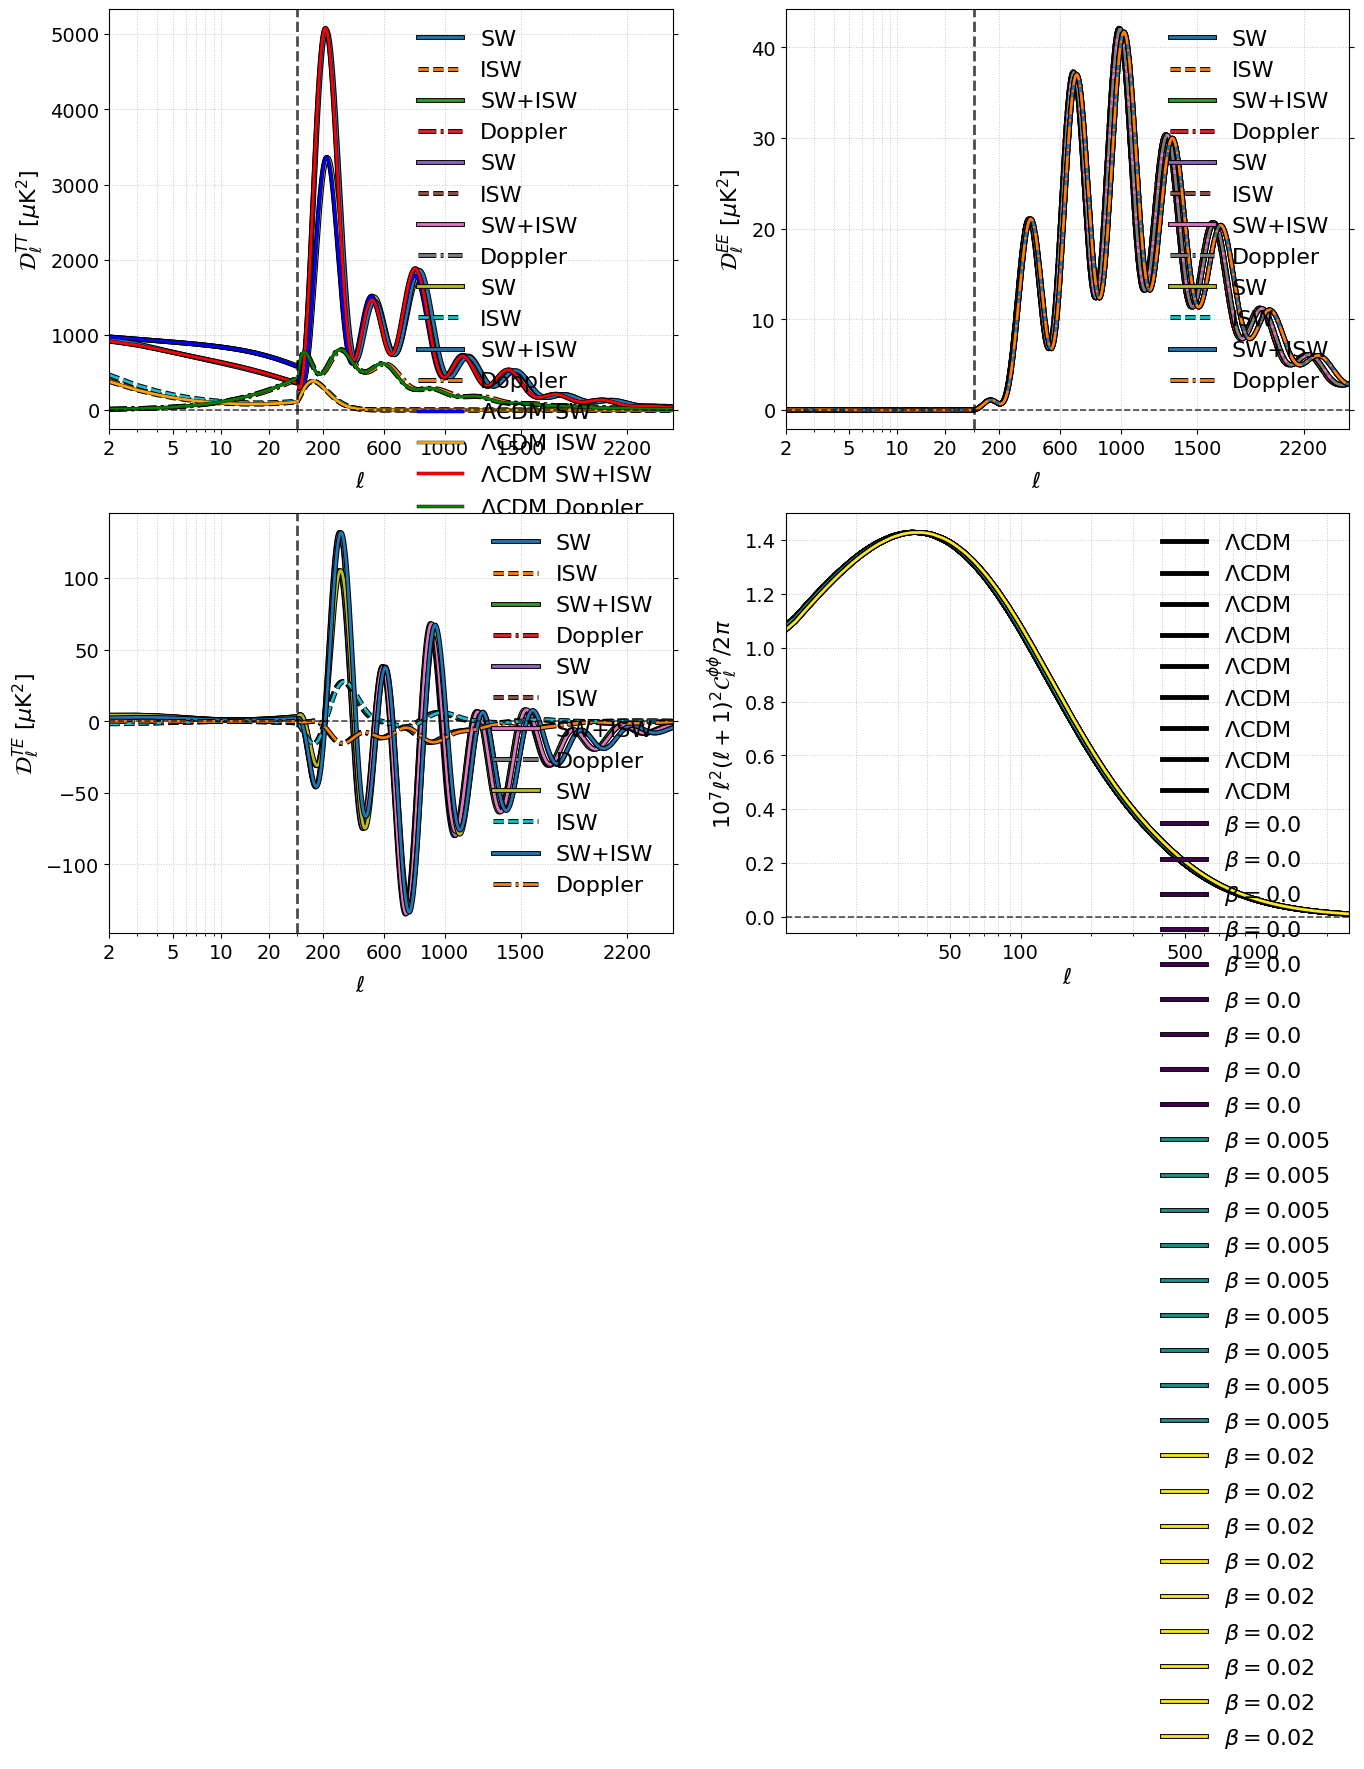

In [6]:
import matplotlib.gridspec as gridspec
from matplotlib.ticker import ScalarFormatter

%matplotlib inline

### Plot the power spectra with split-axis approach
T0 = 2.7255  # CMB temperature in K

# Create figure with custom layout
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], wspace=0.2, hspace=0.2)

linestyles = {
    'tsw': '-',
    'eisw, lisw': '--',
    'tsw, eisw, lisw': '-',
    'tsw, eisw, lisw, dop': '-.',
    'dop': '-.',
    'pol': ':',
    'tsw, eisw, lisw, dop, pol': '-'
}

labels = {
    'tsw': r'SW',
    'eisw, lisw': r'ISW',
    'tsw, eisw, lisw': r'SW+ISW',
    'tsw, eisw, lisw, dop': r'SW+ISW+Doppler',
    'dop': r'Doppler',
    'pol': r'Polarization',
    'tsw, eisw, lisw, dop, pol': r'Full'
}

# Subplot configurations
subplot_configs = [
    (0, 'TT', clTT, r'$\mathcal{D}_\ell^{TT}$ [$\mu$K$^2$]', lambda cl, ell: cl*ell*(ell+1)/(2*np.pi)*1e12*T0**2),
    (1, 'EE', clEE, r'$\mathcal{D}_\ell^{EE}$ [$\mu$K$^2$]', lambda cl, ell: cl*ell*(ell+1)/(2*np.pi)*1e12*T0**2),
    (2, 'TE', clTE, r'$\mathcal{D}_\ell^{TE}$ [$\mu$K$^2$]', lambda cl, ell: cl*ell*(ell+1)/(2*np.pi)*1e12*T0**2),
    (3, 'PP', clPP, r'$10^{7}\ell^2(\ell+1)^2\mathcal{C}_\ell^{\phi\phi}/2\pi$', lambda cl, ell: cl*(ell*(ell+1))**2/(2*np.pi)*1e7)
]

# Custom plotting function for split-axis plots
def create_split_axis_subplot(fig, gs, row_col, ell, cl, label_func, ylabel, is_pp=False):
    # Create subplot grid
    if is_pp:
        # PP plot uses standard log scale
        ax = fig.add_subplot(gs[row_col])
        ax.set_xscale('log')
        ax.set_xlim(10, 2500)
        ax_log = ax
        for temp_contribution in temp_contributions.values():
            linestyle = '--' if gauge == 'sync' else '-'
            ax.plot(ll_lcdm[temp_contribution], clPP_lcdm[temp_contribution]*(ll_lcdm[temp_contribution]*(ll_lcdm[temp_contribution]+1))**2/(2*np.pi)*1e7, linewidth=2, 
                label= rf'$\Lambda$CDM' if gauge == 'new' else None, 
                ls=linestyle, color = 'black', 
                path_effects=[pe.withStroke(linewidth=3.5, foreground='black')])
        for beta, temp_contribution in itertools.product(beta_lrm, temp_contributions.values()):
            color = beta_colors[beta]
            ax.plot(ell[beta, temp_contribution], cl[beta, temp_contribution]*(ell[beta, temp_contribution]*(ell[beta, temp_contribution]+1))**2/(2*np.pi)*1e7, linewidth=2, 
                    label=rf'$\beta = {beta}$' if gauge == 'new' else None,
                    path_effects=[pe.withStroke(linewidth=3.5, foreground='black')], color=color)
        ax.axhline(y=0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
        ax.grid(which='both', linestyle=':', linewidth=0.7, alpha=0.7)
        ax.set_xlabel(r'$\ell$', fontsize=16)
        ax.set_ylabel(r'$10^{7}\ell^2(\ell+1)^2\mathcal{C}_\ell^{\phi\phi}/2\pi$', fontsize=16)
        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.set_xticks([50, 100, 500, 1000])
        ax.get_xaxis().set_major_formatter(ScalarFormatter())
        return ax
    
    # Create GridSpec for split-axis plots
    gs_sub = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[row_col], 
                                               width_ratios=[1, 2], wspace=0.0)
    
    # Left subplot (log scale)
    ax_log = fig.add_subplot(gs_sub[0])
    ax_log.set_xscale('log')
    ax_log.set_xlim(2, 30)
    
    # Right subplot (linear scale)
    ax_lin = fig.add_subplot(gs_sub[1], sharey=ax_log)
    ax_lin.set_xlim(30, 2500)
    
    # Remove spines between the two plots
    ax_log.spines['right'].set_visible(False)
    ax_lin.spines['left'].set_visible(False)
    ax_log.yaxis.tick_left()
    ax_lin.yaxis.tick_right()

    test_temp_contributions = ['tsw', 'eisw, lisw', 'tsw, eisw, lisw', 'dop']
    
    # Plot spectra for each beta
    for beta, temp_contribution in itertools.product(beta_lrm, test_temp_contributions):
        # Prepare data masks
        mask_log = ell[beta, temp_contribution] < 30
        mask_lin = ell[beta, temp_contribution] >= 30
        
        # Compute plotted values
        D_ell_log = label_func(cl[beta, temp_contribution][mask_log], ell[beta, temp_contribution][mask_log])
        D_ell_lin = label_func(cl[beta, temp_contribution][mask_lin], ell[beta, temp_contribution][mask_lin])
        
        color = beta_colors[beta]
        # Line properties
        line_kwargs = {
            'linewidth': 2, 
            'path_effects': [pe.withStroke(linewidth=3.5, foreground='black')],
            'label': labels[temp_contribution], 
            #'color': color,
            'linestyle': linestyles[temp_contribution] if temp_contribution in linestyles else '-'
        }
        
        # Plot on both axes
        ax_log.plot(ell[beta, temp_contribution][mask_log], D_ell_log, **line_kwargs)
        ax_lin.plot(ell[beta, temp_contribution][mask_lin], D_ell_lin, **line_kwargs)
    for temp_contribution in test_temp_contributions:
        if name == 'TT':
            linestyle = linestyles[temp_contribution]
            if temp_contribution == 'tsw, eisw, lisw, dop, pol':
                ax_log.plot(ll_lcdm[temp_contribution][mask_log], clTT_lcdm[temp_contribution][mask_log]*ll_lcdm[temp_contribution][mask_log]*(ll_lcdm[temp_contribution][mask_log]+1)/(2*np.pi)*1e12*T0**2, 
                                linewidth=2, ls='-', color = 'black', 
                                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
                ax_lin.plot(ll_lcdm[temp_contribution][mask_lin], clTT_lcdm[temp_contribution][mask_lin]*ll_lcdm[temp_contribution][mask_lin]*(ll_lcdm[temp_contribution][mask_lin]+1)/(2*np.pi)*1e12*T0**2, 
                                linewidth=2, 
                                label= rf'Full $\Lambda$CDM', 
                                ls='-',
                                color = 'black', 
                                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
            if temp_contribution == 'eisw, lisw':
                ax_log.plot(ll_lcdm[temp_contribution][mask_log], clTT_lcdm[temp_contribution][mask_log]*ll_lcdm[temp_contribution][mask_log]*(ll_lcdm[temp_contribution][mask_log]+1)/(2*np.pi)*1e12*T0**2, 
                                linewidth=2, ls='-', color = 'orange', 
                                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
                ax_lin.plot(ll_lcdm[temp_contribution][mask_lin], clTT_lcdm[temp_contribution][mask_lin]*ll_lcdm[temp_contribution][mask_lin]*(ll_lcdm[temp_contribution][mask_lin]+1)/(2*np.pi)*1e12*T0**2, 
                                linewidth=2, 
                                label= rf'$\Lambda$CDM ISW', 
                                ls='-',
                                color = 'orange', 
                                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
            if temp_contribution == 'dop':
                ax_log.plot(ll_lcdm[temp_contribution][mask_log], clTT_lcdm[temp_contribution][mask_log]*ll_lcdm[temp_contribution][mask_log]*(ll_lcdm[temp_contribution][mask_log]+1)/(2*np.pi)*1e12*T0**2, 
                                linewidth=2, ls='-', color = 'green', 
                                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
                ax_lin.plot(ll_lcdm[temp_contribution][mask_lin], clTT_lcdm[temp_contribution][mask_lin]*ll_lcdm[temp_contribution][mask_lin]*(ll_lcdm[temp_contribution][mask_lin]+1)/(2*np.pi)*1e12*T0**2, 
                                linewidth=2, 
                                label= rf'$\Lambda$CDM Doppler', 
                                ls='-',
                                color = 'green', 
                                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
            if temp_contribution == 'tsw':
                ax_log.plot(ll_lcdm[temp_contribution][mask_log], clTT_lcdm[temp_contribution][mask_log]*ll_lcdm[temp_contribution][mask_log]*(ll_lcdm[temp_contribution][mask_log]+1)/(2*np.pi)*1e12*T0**2, 
                                linewidth=2, ls='-', color = 'blue', 
                                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
                ax_lin.plot(ll_lcdm[temp_contribution][mask_lin], clTT_lcdm[temp_contribution][mask_lin]*ll_lcdm[temp_contribution][mask_lin]*(ll_lcdm[temp_contribution][mask_lin]+1)/(2*np.pi)*1e12*T0**2, 
                                linewidth=2, 
                                label= rf'$\Lambda$CDM SW', 
                                ls='-',
                                color = 'blue', 
                                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
            if temp_contribution == 'pol':
                ax_log.plot(ll_lcdm[temp_contribution][mask_log], clTT_lcdm[temp_contribution][mask_log]*ll_lcdm[temp_contribution][mask_log]*(ll_lcdm[temp_contribution][mask_log]+1)/(2*np.pi)*1e12*T0**2, 
                                linewidth=2, ls='-', color = 'red', 
                                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
                ax_lin.plot(ll_lcdm[temp_contribution][mask_lin], clTT_lcdm[temp_contribution][mask_lin]*ll_lcdm[temp_contribution][mask_lin]*(ll_lcdm[temp_contribution][mask_lin]+1)/(2*np.pi)*1e12*T0**2, 
                                linewidth=2, 
                                label= rf'$\Lambda$CDM Polarization', 
                                ls='-',
                                color = 'red', 
                                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
            if temp_contribution == 'tsw, eisw, lisw':
                ax_log.plot(ll_lcdm[temp_contribution][mask_log], clTT_lcdm[temp_contribution][mask_log]*ll_lcdm[temp_contribution][mask_log]*(ll_lcdm[temp_contribution][mask_log]+1)/(2*np.pi)*1e12*T0**2, 
                                linewidth=2, ls='-', color = 'red', 
                                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
                ax_lin.plot(ll_lcdm[temp_contribution][mask_lin], clTT_lcdm[temp_contribution][mask_lin]*ll_lcdm[temp_contribution][mask_lin]*(ll_lcdm[temp_contribution][mask_lin]+1)/(2*np.pi)*1e12*T0**2, 
                                linewidth=2, 
                                label= rf'$\Lambda$CDM SW+ISW', 
                                ls='-',
                                color = 'red', 
                                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
        if name == 'EE':
            if temp_contribution == 'tsw, eisw, lisw, dop, pol':
                ax_log.plot(ll_lcdm[temp_contribution][mask_log], clEE_lcdm[temp_contribution][mask_log]*ll_lcdm[temp_contribution][mask_log]*(ll_lcdm[temp_contribution][mask_log]+1)/(2*np.pi)*1e12*T0**2, 
                            linewidth=2, ls='-', color = 'black', 
                            path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
                ax_lin.plot(ll_lcdm[temp_contribution][mask_lin], clEE_lcdm[temp_contribution][mask_lin]*ll_lcdm[temp_contribution][mask_lin]*(ll_lcdm[temp_contribution][mask_lin]+1)/(2*np.pi)*1e12*T0**2, 
                                linewidth=2, 
                                label= rf'$\Lambda$CDM',
                                ls='-', 
                                color = 'black', 
                                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
        if name == 'TE':
            if temp_contribution == 'tsw, eisw, lisw, dop, pol':
                ax_log.plot(ll_lcdm[temp_contribution][mask_log], clTE_lcdm[temp_contribution][mask_log]*ll_lcdm[temp_contribution][mask_log]*(ll_lcdm[temp_contribution][mask_log]+1)/(2*np.pi)*1e12*T0**2, 
                            linewidth=2, ls='-', color = 'black', 
                            path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
                ax_lin.plot(ll_lcdm[temp_contribution][mask_lin], clTE_lcdm[temp_contribution][mask_lin]*ll_lcdm[temp_contribution][mask_lin]*(ll_lcdm[temp_contribution][mask_lin]+1)/(2*np.pi)*1e12*T0**2, 
                            linewidth=2, 
                            label= rf'$\Lambda$CDM',
                            ls='--' if temp_contribution == 'tsw' else '-',
                            color = 'black', 
                            path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
    
    # Formatting
    ax_log.set_ylabel(ylabel, fontsize=16)
    ax_lin.set_xlabel(r'$\ell$', fontsize=16)
    ax_lin.xaxis.set_label_coords(1/6, -0.1)
    for ax in [ax_log, ax_lin]:
        ax.grid(which='both', linestyle=':', linewidth=0.7, alpha=0.7)
        ax.axhline(y=0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
        ax.axvline(x=30, color='black', linestyle='--', linewidth=2, alpha=0.7)
        ax.tick_params(axis='both', which='major', labelsize=14)
    
    # Tick formatting
    ax_log.set_xticks([2, 5, 10, 20])
    ax_lin.set_xticks([200, 600, 1000, 1500, 2200])
    for ax in [ax_log, ax_lin]:
        ax.get_xaxis().set_major_formatter(ScalarFormatter())
    
    # Tick visibility
    ax_log.tick_params(labelleft=True, labelright=False)
    ax_lin.tick_params(labelleft=False, labelright=False)
    
    # Legend
    ax_lin.legend(fontsize=16, loc='upper right', frameon=False)
    
    return ax_log, ax_lin

# Create subplots
for (idx, name, cl_dict, ylabel, label_func) in subplot_configs:
    is_pp = (name == 'PP')
    if is_pp:
        # PP plot is different (standard log scale)
        ax = create_split_axis_subplot(fig, gs, idx, ll, cl_dict, label_func, ylabel, is_pp=True)
        ax.legend(fontsize=16, loc='upper right', frameon=False)
    else:
        # TT, EE, TE plots use split-axis
        create_split_axis_subplot(fig, gs, idx, ll, cl_dict, label_func, ylabel)
        
fig.savefig('power_spectra_contributions_sync.pdf', dpi=300, bbox_inches='tight')


#plt.tight_layout()
plt.show()

/tmp/ipykernel_129524/274636895.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


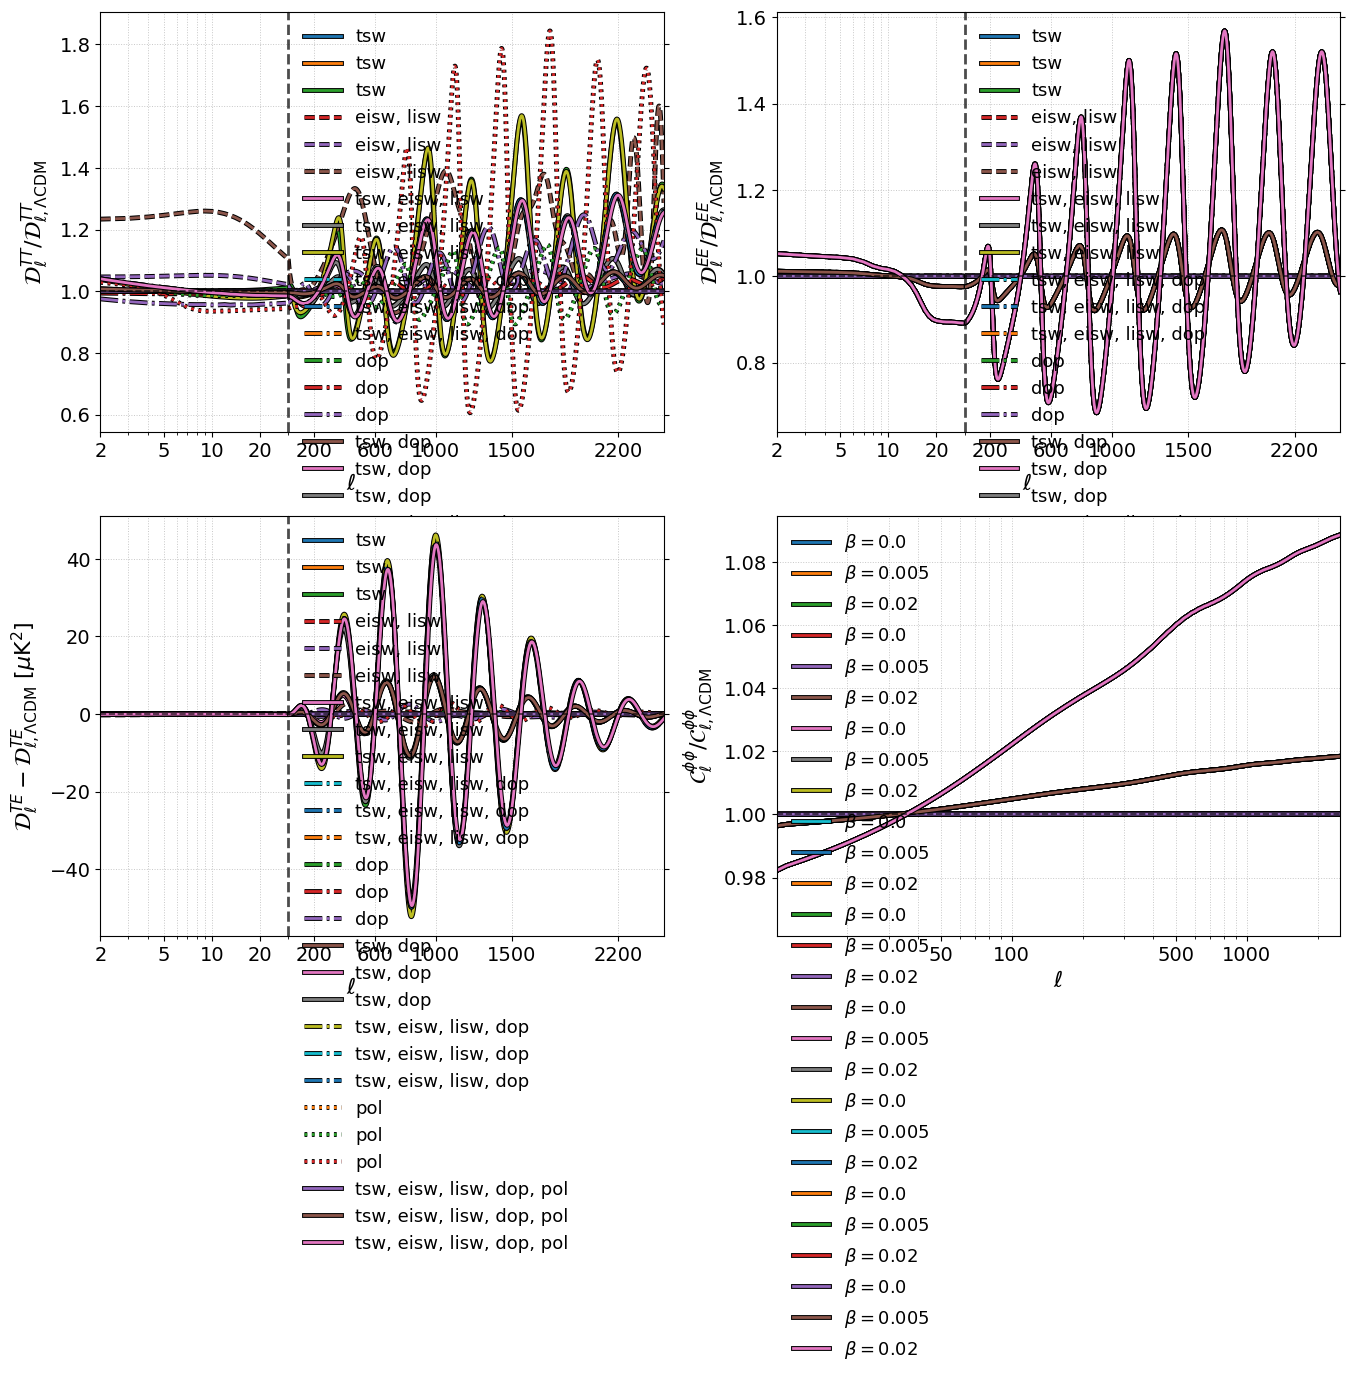

In [7]:
import matplotlib.gridspec as gridspec
from matplotlib.ticker import ScalarFormatter

T0 = 2.7255  # CMB temperature in K

# Create figure with custom layout
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], wspace=0.2, hspace=0.2)

# Plot configurations
subplot_configs = [
    (0, 'TT', clTT, clTT_lcdm, r'$\mathcal{D}_\ell^{TT}/\mathcal{D}_{\ell, \Lambda \mathrm{CDM}}^{TT}$', lambda cl, cl_lcdm: cl / cl_lcdm),
    (1, 'EE', clEE, clEE_lcdm, r'$\mathcal{D}_\ell^{EE}/\mathcal{D}_{\ell, \Lambda \mathrm{CDM}}^{EE}$', lambda cl, cl_lcdm: cl / cl_lcdm),
    (2, 'TE', clTE, clTE_lcdm, r'$\mathcal{D}_\ell^{TE} - \mathcal{D}_{\ell, \Lambda \mathrm{CDM}}^{TE}$ [$\mu$K$^2$]', lambda cl, cl_lcdm, ell: (cl - cl_lcdm) * ell * (ell + 1) / (2 * np.pi) * 1e12 * T0**2),
    (3, 'PP', clPP, clPP_lcdm, r'$\mathcal{C}_\ell^{\phi\phi}/\mathcal{C}_{\ell, \Lambda \mathrm{CDM}}^{\phi\phi}$', lambda cl, cl_lcdm: cl / cl_lcdm)
]

# Main plotting function (now includes gauge)
def create_split_axis_subplot(fig, gs, row_col, ell, cl, cl_lcdm, label_func, ylabel, is_pp=False, is_te=False, idx=None):
    if is_pp:
        ax = fig.add_subplot(gs[row_col])
        ax.set_xscale('log')
        ax.set_xlim(10, 2500)

        for temp_contribution in temp_contributions.values():
            for beta in beta_lrm:
                #color = beta_colors[beta]
                ax.plot(ell[beta, temp_contribution], label_func(cl[beta, temp_contribution], cl_lcdm[temp_contribution]), linewidth=2,
                        label=rf'$\beta = {beta}$',
                        linestyle='-',
                        path_effects=[pe.withStroke(linewidth=3.5, foreground='black')])
        
        ax.axhline(y=1, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
        ax.grid(which='both', linestyle=':', linewidth=0.7, alpha=0.7)
        ax.set_xlabel(r'$\ell$', fontsize=16)
        ax.set_ylabel(ylabel, fontsize=16)
        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.set_xticks([50, 100, 500, 1000])
        ax.get_xaxis().set_major_formatter(ScalarFormatter())
        ax.legend(fontsize=13, loc='upper left', frameon=False)
        return ax

    gs_sub = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[row_col], width_ratios=[1, 2], wspace=0.0)
    ax_log = fig.add_subplot(gs_sub[0])
    ax_lin = fig.add_subplot(gs_sub[1], sharey=ax_log)

    ax_log.set_xscale('log')
    ax_log.set_xlim(2, 30)
    ax_lin.set_xlim(30, 2500)

    ax_log.spines['right'].set_visible(False)
    ax_lin.spines['left'].set_visible(False)
    ax_log.yaxis.tick_left()
    ax_lin.yaxis.tick_right()

    for temp_contribution in temp_contributions.values():
        for beta in beta_lrm:
            color = beta_colors[beta]
            mask_log = ell[beta, temp_contribution] < 30
            mask_lin = ell[beta, temp_contribution] >= 30

            if is_te:
                D_ell_log = label_func(cl[beta, temp_contribution][mask_log], cl_lcdm[temp_contribution][mask_log], ell[beta, temp_contribution][mask_log])
                D_ell_lin = label_func(cl[beta, temp_contribution][mask_lin], cl_lcdm[temp_contribution][mask_lin], ell[beta, temp_contribution][mask_lin])
            else:
                D_ell_log = label_func(cl[beta, temp_contribution][mask_log], cl_lcdm[temp_contribution][mask_log])
                D_ell_lin = label_func(cl[beta, temp_contribution][mask_lin], cl_lcdm[temp_contribution][mask_lin])

            line_kwargs = {
                'linewidth': 2,
                'path_effects': [pe.withStroke(linewidth=3.5, foreground='black')],
                'label': rf'{temp_contribution}',
                'linestyle': linestyles[temp_contribution] if temp_contribution in linestyles else '-',
            }

            ax_log.plot(ell[beta, temp_contribution][mask_log], D_ell_log, **line_kwargs)
            ax_lin.plot(ell[beta, temp_contribution][mask_lin], D_ell_lin, **line_kwargs)

    ax_log.set_ylabel(ylabel, fontsize=16)
    ax_lin.set_xlabel(r'$\ell$', fontsize=16)
    ax_lin.xaxis.set_label_coords(1 / 6, -0.1)

    for ax in [ax_log, ax_lin]:
        ax.grid(which='both', linestyle=':', linewidth=0.7, alpha=0.7)
        ax.axvline(x=30, color='black', linestyle='--', linewidth=2, alpha=0.7)
        if is_te:
            ax.axhline(y=0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
        else:
            ax.axhline(y=1, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
        ax.tick_params(axis='both', which='major', labelsize=14)

    ax_log.set_xticks([2, 5, 10, 20])
    ax_lin.set_xticks([200, 600, 1000, 1500, 2200])
    for ax in [ax_log, ax_lin]:
        ax.get_xaxis().set_major_formatter(ScalarFormatter())

    ax_log.tick_params(labelleft=True, labelright=False)
    ax_lin.tick_params(labelleft=False, labelright=False)

    ax_lin.legend(fontsize=13, loc='upper left', frameon=False)

    return ax_log, ax_lin

# Create all subplots
for (idx, name, cl_dict, cl_lcdm_dict, ylabel, label_func) in subplot_configs:
    is_pp = (name == 'PP')
    is_te = (name == 'TE')
    if is_pp:
        create_split_axis_subplot(fig, gs, idx, ll, cl_dict, cl_lcdm_dict, label_func, ylabel, is_pp=True, idx=idx)
    else:
        create_split_axis_subplot(fig, gs, idx, ll, cl_dict, cl_lcdm_dict, label_func, ylabel, is_te=is_te, idx=idx)

fig.savefig('power_spectra_ratios_diff_gauges.pdf', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


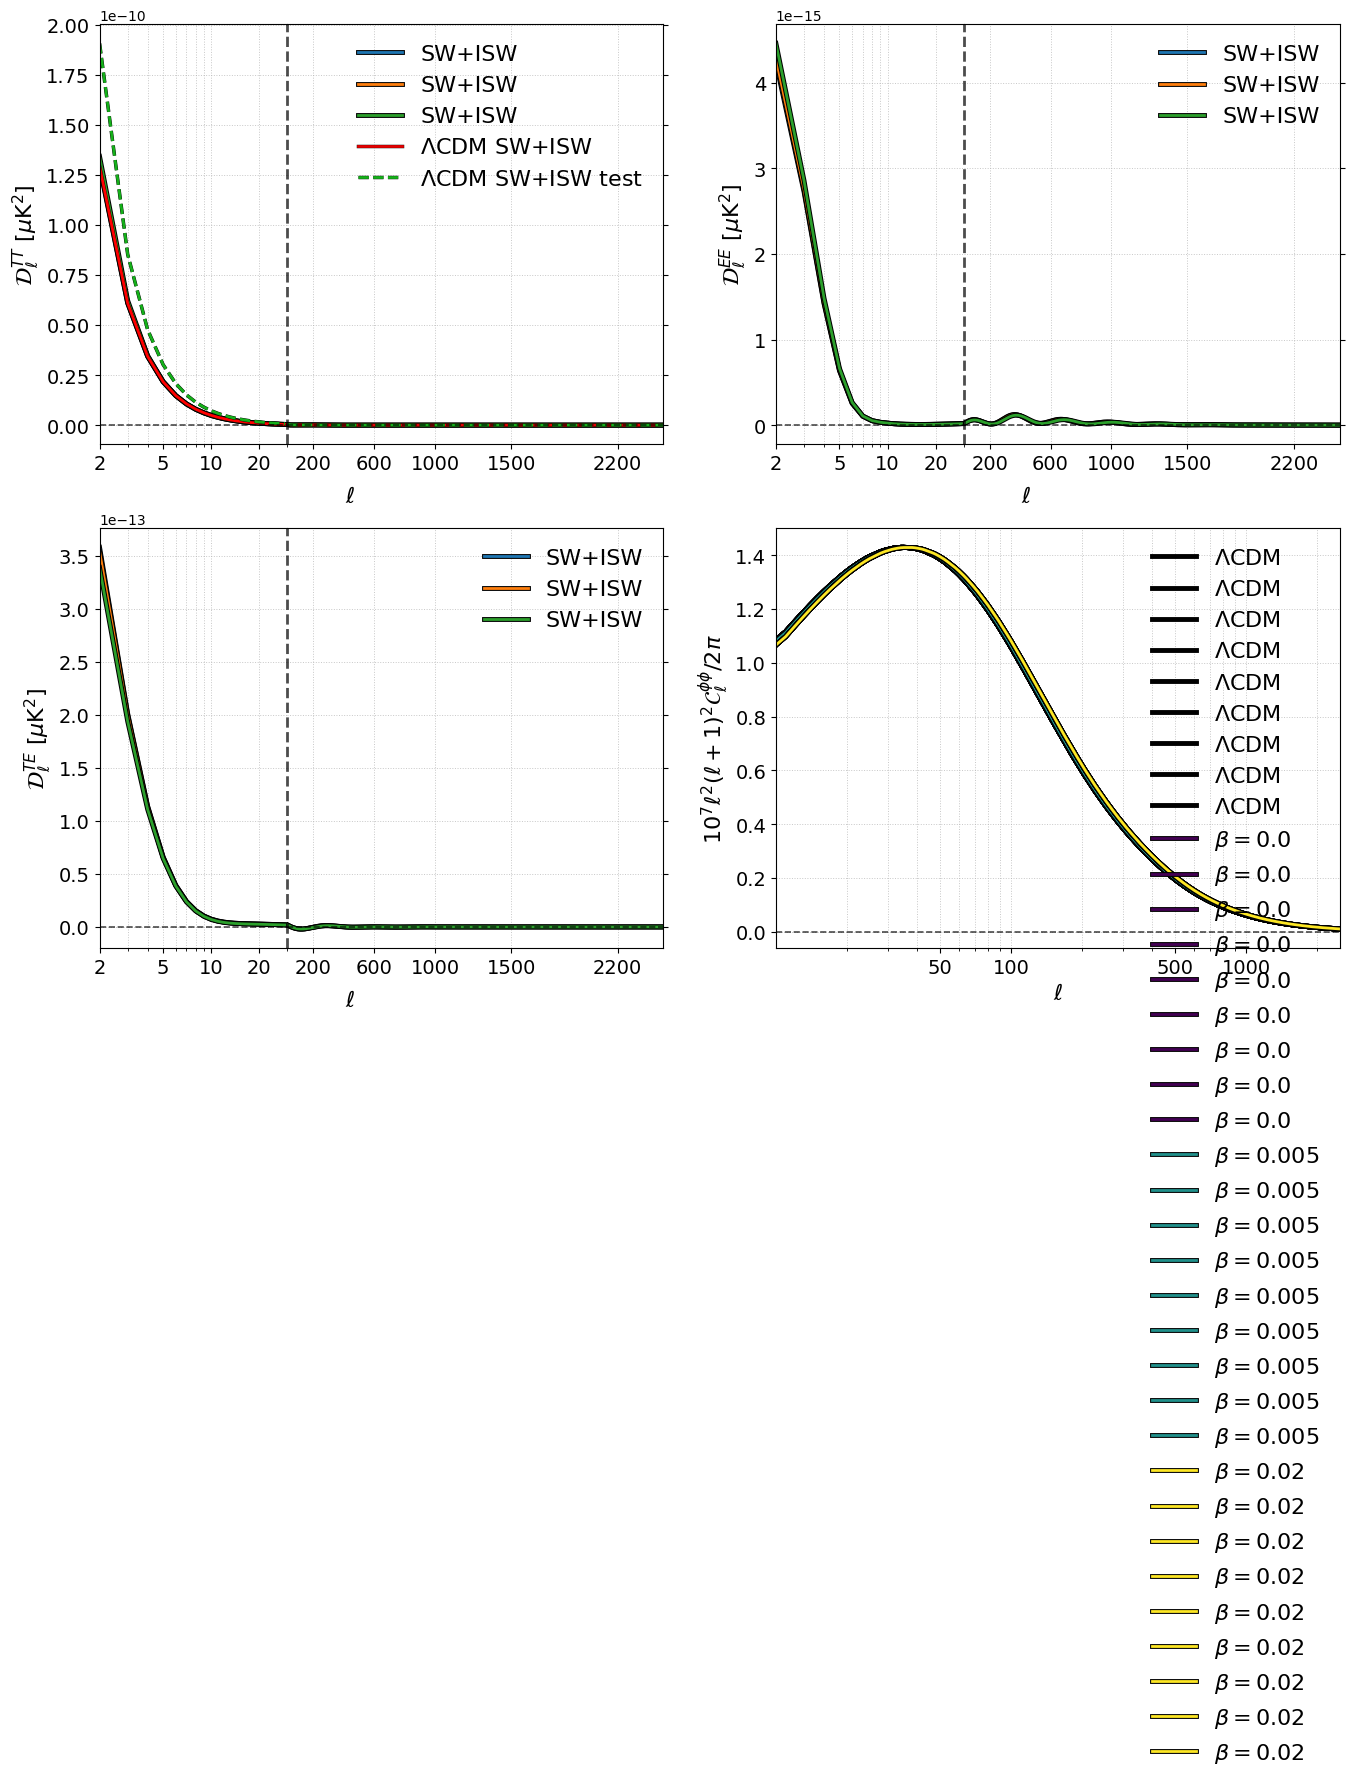

In [8]:
import matplotlib.gridspec as gridspec
from matplotlib.ticker import ScalarFormatter

%matplotlib inline

### Plot the power spectra with split-axis approach
T0 = 2.7255  # CMB temperature in K

# Create figure with custom layout
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], wspace=0.2, hspace=0.2)

linestyles = {
    'tsw': '-',
    'eisw, lisw': '--',
    'tsw, eisw, lisw': '-',
    'tsw, eisw, lisw, dop': '-.',
    'dop': '-.',
    'pol': ':',
    'tsw, eisw, lisw, dop, pol': '-'
}

labels = {
    'tsw': r'SW',
    'eisw, lisw': r'ISW',
    'tsw, eisw, lisw': r'SW+ISW',
    'tsw, eisw, lisw, dop': r'SW+ISW+Doppler',
    'dop': r'Doppler',
    'pol': r'Polarization',
    'tsw, eisw, lisw, dop, pol': r'Full'
}

# Subplot configurations
subplot_configs = [
    (0, 'TT', clTT, r'$\mathcal{D}_\ell^{TT}$ [$\mu$K$^2$]', lambda cl, ell: cl*ell),
    (1, 'EE', clEE, r'$\mathcal{D}_\ell^{EE}$ [$\mu$K$^2$]', lambda cl, ell: cl*ell),
    (2, 'TE', clTE, r'$\mathcal{D}_\ell^{TE}$ [$\mu$K$^2$]', lambda cl, ell: cl*ell),
    (3, 'PP', clPP, r'$10^{7}\ell^2(\ell+1)^2\mathcal{C}_\ell^{\phi\phi}/2\pi$', lambda cl, ell: cl*(ell*(ell+1))**2/(2*np.pi)*1e7)
]

# Custom plotting function for split-axis plots
def create_split_axis_subplot(fig, gs, row_col, ell, cl, label_func, ylabel, is_pp=False):
    # Create subplot grid
    if is_pp:
        # PP plot uses standard log scale
        ax = fig.add_subplot(gs[row_col])
        ax.set_xscale('log')
        ax.set_xlim(10, 2500)
        ax_log = ax
        for temp_contribution in temp_contributions.values():
            linestyle = '--' if gauge == 'sync' else '-'
            ax.plot(ll_lcdm[temp_contribution], clPP_lcdm[temp_contribution]*(ll_lcdm[temp_contribution]*(ll_lcdm[temp_contribution]+1))**2/(2*np.pi)*1e7, linewidth=2, 
                label= rf'$\Lambda$CDM' if gauge == 'new' else None, 
                ls=linestyle, color = 'black', 
                path_effects=[pe.withStroke(linewidth=3.5, foreground='black')])
        for beta, temp_contribution in itertools.product(beta_lrm, temp_contributions.values()):
            color = beta_colors[beta]
            ax.plot(ell[beta, temp_contribution], cl[beta, temp_contribution]*(ell[beta, temp_contribution]*(ell[beta, temp_contribution]+1))**2/(2*np.pi)*1e7, linewidth=2, 
                    label=rf'$\beta = {beta}$' if gauge == 'new' else None,
                    path_effects=[pe.withStroke(linewidth=3.5, foreground='black')], color=color)
        ax.axhline(y=0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
        ax.grid(which='both', linestyle=':', linewidth=0.7, alpha=0.7)
        ax.set_xlabel(r'$\ell$', fontsize=16)
        ax.set_ylabel(r'$10^{7}\ell^2(\ell+1)^2\mathcal{C}_\ell^{\phi\phi}/2\pi$', fontsize=16)
        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.set_xticks([50, 100, 500, 1000])
        ax.get_xaxis().set_major_formatter(ScalarFormatter())
        return ax
    
    # Create GridSpec for split-axis plots
    gs_sub = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[row_col], 
                                               width_ratios=[1, 2], wspace=0.0)
    
    # Left subplot (log scale)
    ax_log = fig.add_subplot(gs_sub[0])
    ax_log.set_xscale('log')
    ax_log.set_xlim(2, 30)
    
    # Right subplot (linear scale)
    ax_lin = fig.add_subplot(gs_sub[1], sharey=ax_log)
    ax_lin.set_xlim(30, 2500)
    
    # Remove spines between the two plots
    ax_log.spines['right'].set_visible(False)
    ax_lin.spines['left'].set_visible(False)
    ax_log.yaxis.tick_left()
    ax_lin.yaxis.tick_right()

    test_temp_contributions = ['tsw, eisw, lisw']
    
    # Plot spectra for each beta
    for beta, temp_contribution in itertools.product(beta_lrm, test_temp_contributions):
        # Prepare data masks
        mask_log = ell[beta, temp_contribution] < 30
        mask_lin = ell[beta, temp_contribution] >= 30
        
        # Compute plotted values
        # D_ell_log = label_func(cl[beta, temp_contribution][mask_log], ell[beta, temp_contribution][mask_log])
        # D_ell_lin = label_func(cl[beta, temp_contribution][mask_lin], ell[beta, temp_contribution][mask_lin])
        
        color = beta_colors[beta]
        # Line properties
        line_kwargs = {
            'linewidth': 2, 
            'path_effects': [pe.withStroke(linewidth=3.5, foreground='black')],
            'label': labels[temp_contribution], 
            'linestyle': linestyles[temp_contribution] if temp_contribution in linestyles else '-'
        }
        
        # Plot on both axes
        ax_log.plot(ell[beta, temp_contribution][mask_log], cl[beta, temp_contribution][mask_log], **line_kwargs)
        ax_lin.plot(ell[beta, temp_contribution][mask_lin], cl[beta, temp_contribution][mask_lin], **line_kwargs)
    for temp_contribution in test_temp_contributions:
        if name == 'TT':
            linestyle = linestyles[temp_contribution]
            if temp_contribution == 'tsw, eisw, lisw, dop, pol':
                ax_log.plot(ll_lcdm[temp_contribution][mask_log], clTT_lcdm[temp_contribution][mask_log], 
                                linewidth=2, ls='-', color = 'black', 
                                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
                ax_lin.plot(ll_lcdm[temp_contribution][mask_lin], clTT_lcdm[temp_contribution][mask_lin], 
                                linewidth=2, 
                                label= rf'Full $\Lambda$CDM', 
                                ls='-',
                                color = 'black', 
                                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
            if temp_contribution == 'eisw, lisw':
                ax_log.plot(ll_lcdm[temp_contribution][mask_log], clTT_lcdm[temp_contribution][mask_log], 
                                linewidth=2, ls='-', color = 'orange', 
                                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
                ax_lin.plot(ll_lcdm[temp_contribution][mask_lin], clTT_lcdm[temp_contribution][mask_lin], 
                                linewidth=2, 
                                label= rf'$\Lambda$CDM ISW', 
                                ls='-',
                                color = 'orange', 
                                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
            if temp_contribution == 'dop':
                ax_log.plot(ll_lcdm[temp_contribution][mask_log], clTT_lcdm[temp_contribution][mask_log], 
                                linewidth=2, ls='-', color = 'green', 
                                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
                ax_lin.plot(ll_lcdm[temp_contribution][mask_lin], clTT_lcdm[temp_contribution][mask_lin], 
                                linewidth=2, 
                                label= rf'$\Lambda$CDM Doppler', 
                                ls='-',
                                color = 'green', 
                                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
            if temp_contribution == 'tsw':
                ax_log.plot(ll_lcdm[temp_contribution][mask_log], clTT_lcdm[temp_contribution][mask_log], 
                                linewidth=2, ls='-', color = 'blue', 
                                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
                ax_lin.plot(ll_lcdm[temp_contribution][mask_lin], clTT_lcdm[temp_contribution][mask_lin], 
                                linewidth=2, 
                                label= rf'$\Lambda$CDM SW', 
                                ls='-',
                                color = 'blue', 
                                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
            if temp_contribution == 'pol':
                ax_log.plot(ll_lcdm[temp_contribution][mask_log], clTT_lcdm[temp_contribution][mask_log], 
                                linewidth=2, ls='-', color = 'red', 
                                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
                ax_lin.plot(ll_lcdm[temp_contribution][mask_lin], clTT_lcdm[temp_contribution][mask_lin], 
                                linewidth=2, 
                                label= rf'$\Lambda$CDM Polarization', 
                                ls='-',
                                color = 'red', 
                                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
            if temp_contribution == 'tsw, eisw, lisw':
                ax_log.plot(ll_lcdm[temp_contribution][mask_log], clTT_lcdm[temp_contribution][mask_log], 
                                linewidth=2, ls='-', color = 'red', 
                                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
                ax_lin.plot(ll_lcdm[temp_contribution][mask_lin], clTT_lcdm[temp_contribution][mask_lin], 
                                linewidth=2, 
                                label= rf'$\Lambda$CDM SW+ISW', 
                                ls='-',
                                color = 'xkcd:red', 
                                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
                ax_log.plot(ll_lcdm[temp_contribution][mask_log], clTT_lcdm['tsw'][mask_log]+clTT_lcdm['eisw, lisw'][mask_log],
                                linewidth=2, ls='--', color = 'xkcd:green', 
                                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
                ax_lin.plot(ll_lcdm[temp_contribution][mask_lin], clTT_lcdm['tsw'][mask_lin]+clTT_lcdm['eisw, lisw'][mask_lin],
                                linewidth=2, 
                                label= rf'$\Lambda$CDM SW+ISW test', 
                                ls='--',
                                color = 'xkcd:green', 
                                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
        if name == 'EE':
            if temp_contribution == 'tsw, eisw, lisw, dop, pol':
                ax_log.plot(ll_lcdm[temp_contribution][mask_log], clEE_lcdm[temp_contribution][mask_log], 
                            linewidth=2, ls='-', color = 'black', 
                            path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
                ax_lin.plot(ll_lcdm[temp_contribution][mask_lin], clEE_lcdm[temp_contribution][mask_lin], 
                                linewidth=2, 
                                label= rf'$\Lambda$CDM',
                                ls='-', 
                                color = 'black', 
                                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
        if name == 'TE':
            if temp_contribution == 'tsw, eisw, lisw, dop, pol':
                ax_log.plot(ll_lcdm[temp_contribution][mask_log], clTE_lcdm[temp_contribution][mask_log], 
                            linewidth=2, ls='-', color = 'black', 
                            path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
                ax_lin.plot(ll_lcdm[temp_contribution][mask_lin], clTE_lcdm[temp_contribution][mask_lin], 
                            linewidth=2, 
                            label= rf'$\Lambda$CDM',
                            ls='--' if temp_contribution == 'tsw' else '-',
                            color = 'black', 
                            path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
    
    # Formatting
    ax_log.set_ylabel(ylabel, fontsize=16)
    ax_lin.set_xlabel(r'$\ell$', fontsize=16)
    ax_lin.xaxis.set_label_coords(1/6, -0.1)
    for ax in [ax_log, ax_lin]:
        ax.grid(which='both', linestyle=':', linewidth=0.7, alpha=0.7)
        ax.axhline(y=0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
        ax.axvline(x=30, color='black', linestyle='--', linewidth=2, alpha=0.7)
        ax.tick_params(axis='both', which='major', labelsize=14)
    
    # Tick formatting
    ax_log.set_xticks([2, 5, 10, 20])
    ax_lin.set_xticks([200, 600, 1000, 1500, 2200])
    for ax in [ax_log, ax_lin]:
        ax.get_xaxis().set_major_formatter(ScalarFormatter())
    
    # Tick visibility
    ax_log.tick_params(labelleft=True, labelright=False)
    ax_lin.tick_params(labelleft=False, labelright=False)
    
    # Legend
    ax_lin.legend(fontsize=16, loc='upper right', frameon=False)
    
    return ax_log, ax_lin

# Create subplots
for (idx, name, cl_dict, ylabel, label_func) in subplot_configs:
    is_pp = (name == 'PP')
    if is_pp:
        # PP plot is different (standard log scale)
        ax = create_split_axis_subplot(fig, gs, idx, ll, cl_dict, label_func, ylabel, is_pp=True)
        ax.legend(fontsize=16, loc='upper right', frameon=False)
    else:
        # TT, EE, TE plots use split-axis
        create_split_axis_subplot(fig, gs, idx, ll, cl_dict, label_func, ylabel)
        
fig.savefig('power_spectra_contributions_sync.pdf', dpi=300, bbox_inches='tight')


#plt.tight_layout()
plt.show()

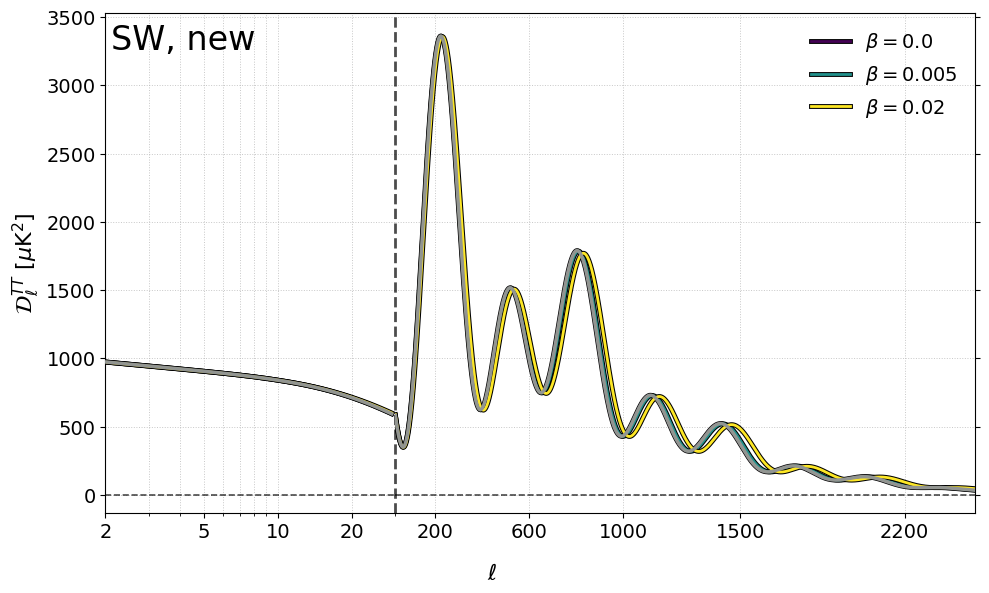

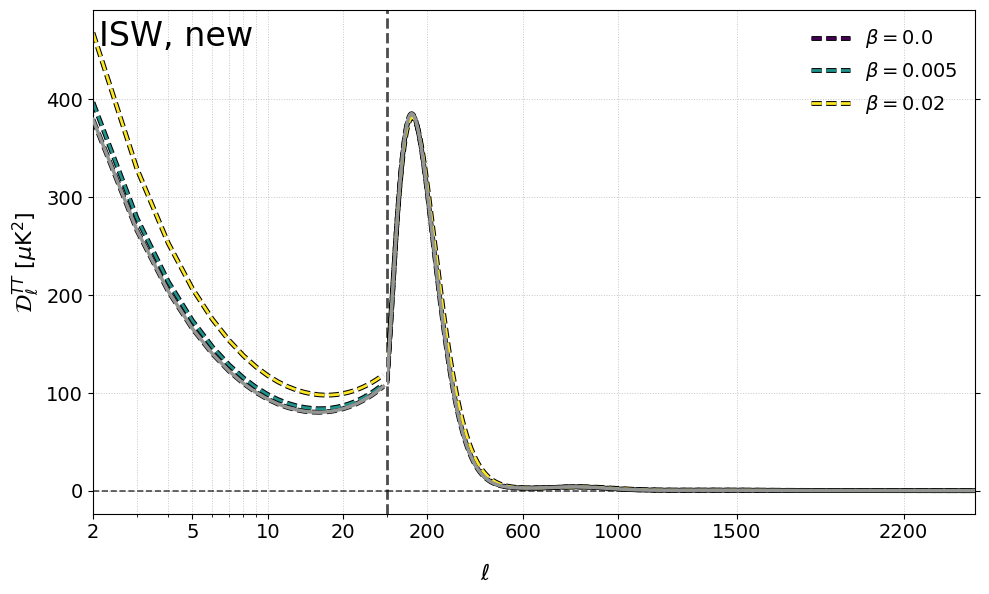

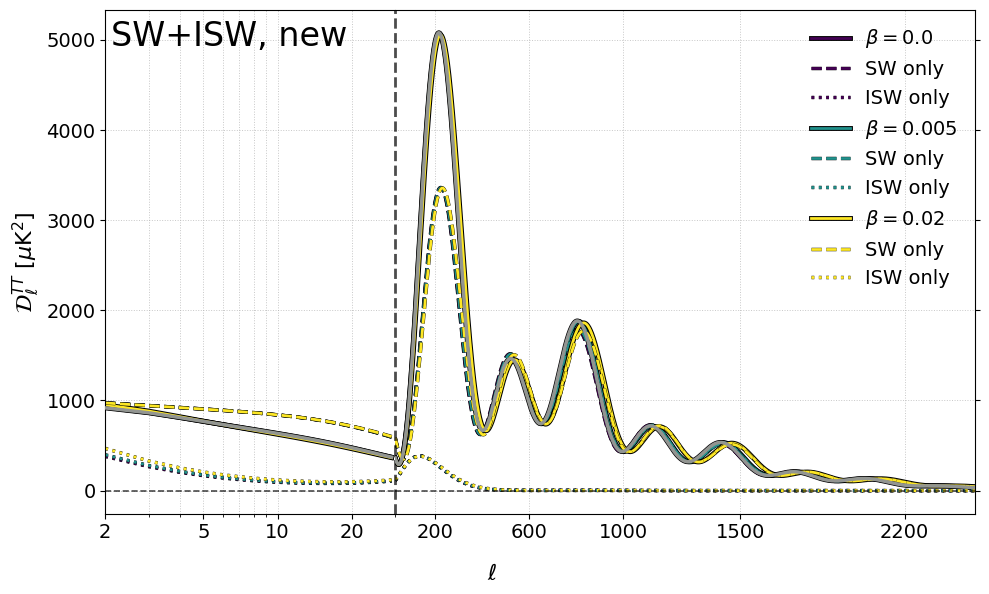

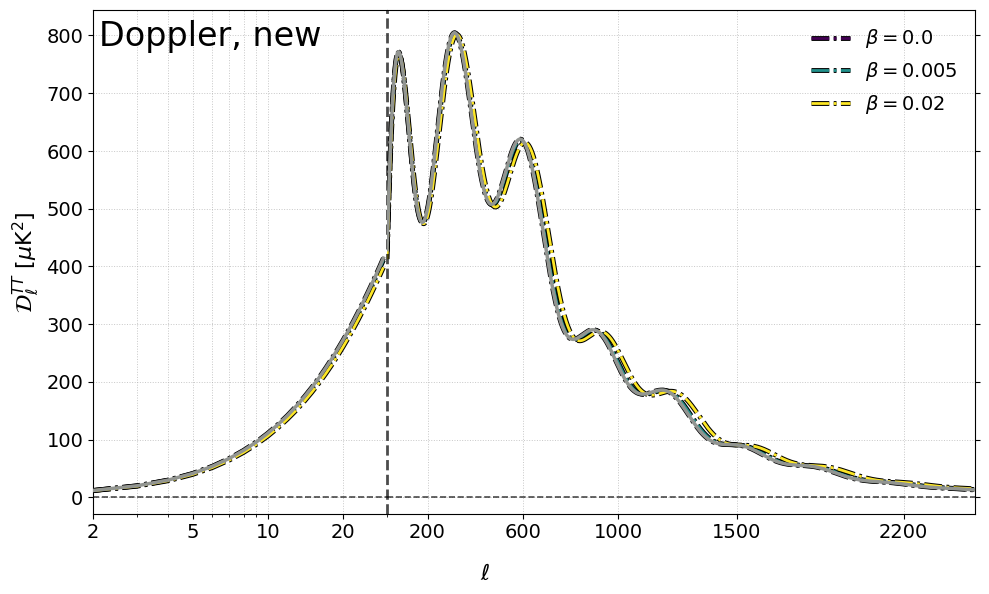

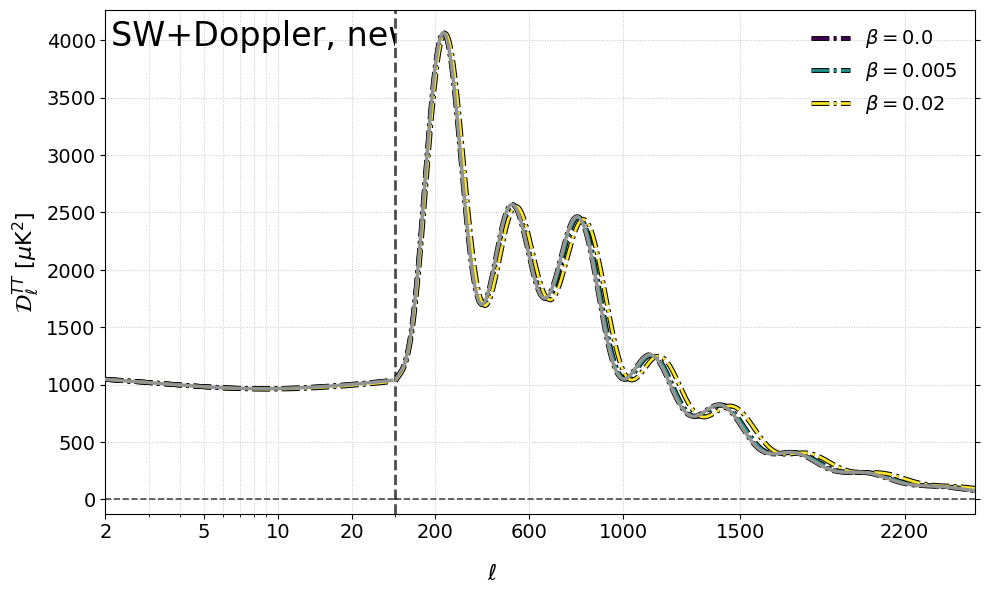

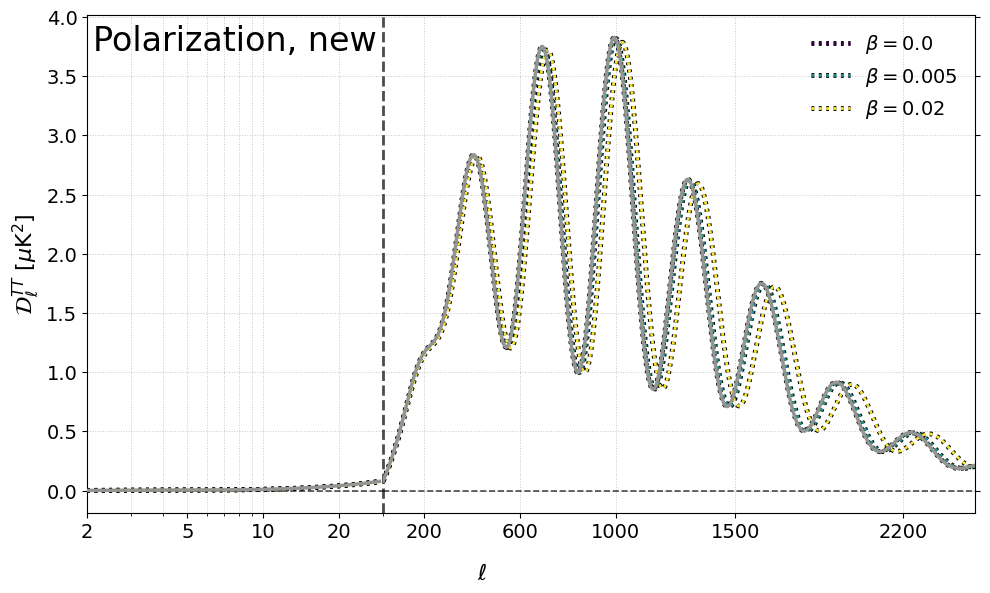

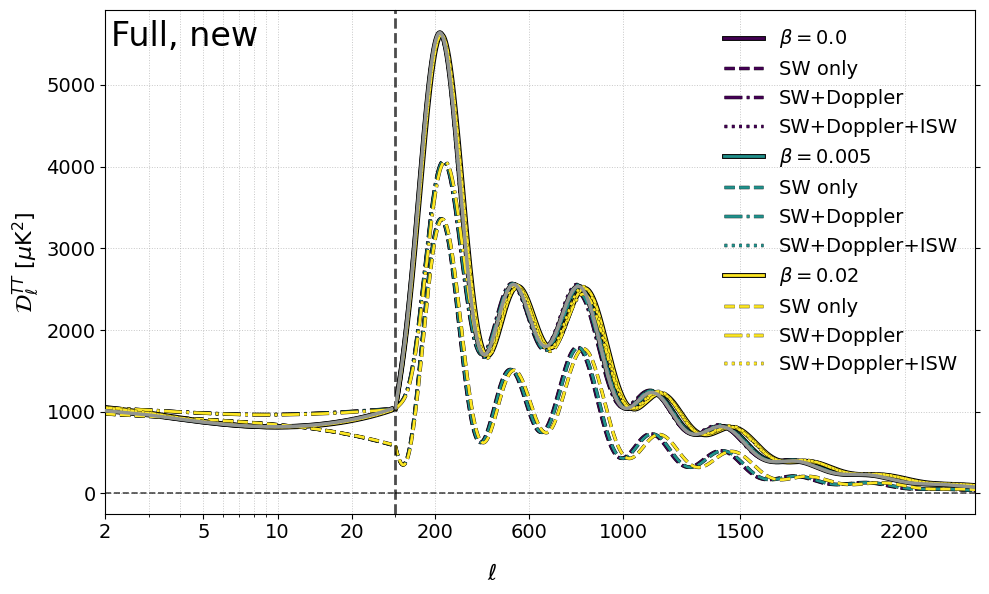

In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as pe
from matplotlib.ticker import ScalarFormatter
import numpy as np
import itertools

# Example: assume variables like clTT, ll, beta_lrm, beta_colors, clTT_lcdm, ll_lcdm, etc. are already defined

# Settings
T0 = 2.7255  # CMB temperature in K

linestyles = {
    'tsw': '-',
    'eisw, lisw': '--',
    'tsw, eisw, lisw': '-',
    'dop': '-.',
    'tsw, dop': '-.',
    'tsw, eisw, lisw, dop': '-.',
    'pol': ':',
    'tsw, eisw, lisw, dop, pol': '-'
}

labels = {
    'tsw': r'SW',
    'eisw, lisw': r'ISW',
    'tsw, eisw, lisw': r'SW+ISW',
    'dop': r'Doppler',
    'tsw, dop': r'SW+Doppler',
    'tsw, eisw, lisw, dop': r'SW+ISW+Doppler',
    'pol': r'Polarization',
    'tsw, eisw, lisw, dop, pol': r'Full'
}

# === Split-Axis TT Plot Function ===
def plot_tt_split_axis(ell, cl, cl_lcdm, ell_lcdm, contribution):
    fig = plt.figure(figsize=(10, 6))
    gs = gridspec.GridSpec(1, 2, width_ratios=[1, 2], wspace=0)

    # Left: log scale for low ell
    ax_log = fig.add_subplot(gs[0])
    ax_log.set_xscale('log')
    ax_log.set_xlim(2, 30)

    # Right: linear scale for high ell
    ax_lin = fig.add_subplot(gs[1], sharey=ax_log)
    ax_lin.set_xlim(30, 2500)

    # Remove spines between plots
    ax_log.spines['right'].set_visible(False)
    ax_lin.spines['left'].set_visible(False)
    ax_log.yaxis.tick_left()
    ax_lin.yaxis.tick_right()

    # Plot each beta model and contribution
    for beta in beta_lrm:
        mask_log = ell[beta, contribution] < 30
        mask_lin = ell[beta, contribution] >= 30

        color = beta_colors[beta]
        label = rf'$\beta = {beta}$'

        line_kwargs = {
            'linewidth': 2,
            'path_effects': [pe.withStroke(linewidth=3.5, foreground='black')],
            'label': label,
            'color': color,
            'linestyle': linestyles.get(contribution, '-')
        }

        ax_log.plot(ell[beta, contribution][mask_log], cl[beta, contribution][mask_log] * ell[beta, contribution][mask_log]*(1+ell[beta, contribution][mask_log])/(2*np.pi)*1e12*T0**2, **line_kwargs)
        ax_lin.plot(ell[beta, contribution][mask_lin], cl[beta, contribution][mask_lin] * ell[beta, contribution][mask_lin]*(1+ell[beta, contribution][mask_lin])/(2*np.pi)*1e12*T0**2, **line_kwargs)
        if contribution == 'tsw, eisw, lisw':
            ax_log.plot(ell[beta, 'tsw'][mask_log], cl[beta, 'tsw'][mask_log] * ell[beta, 'tsw'][mask_log]*(1+ell[beta, 'tsw'][mask_log])/(2*np.pi)*1e12*T0**2,
                        linewidth=2, ls='--', color=color,
                        path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
            ax_lin.plot(ell[beta, 'tsw'][mask_lin], cl[beta, 'tsw'][mask_lin] * ell[beta, 'tsw'][mask_lin]*(1+ell[beta, 'tsw'][mask_lin])/(2*np.pi)*1e12*T0**2,
                        linewidth=2, 
                        label= rf'SW only',
                        ls='--',
                        color=color,
                        path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
            ax_log.plot(ell[beta, 'eisw, lisw'][mask_log], cl[beta, 'eisw, lisw'][mask_log] * ell[beta, 'eisw, lisw'][mask_log]*(1+ell[beta, 'eisw, lisw'][mask_log])/(2*np.pi)*1e12*T0**2,
                        linewidth=2, ls=':', color=color,
                        path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
            ax_lin.plot(ell[beta, 'eisw, lisw'][mask_lin], cl[beta, 'eisw, lisw'][mask_lin] * ell[beta, 'eisw, lisw'][mask_lin]*(1+ell[beta, 'eisw, lisw'][mask_lin])/(2*np.pi)*1e12*T0**2,
                        linewidth=2, 
                        label= rf'ISW only',
                        ls=':',
                        color=color,
                        path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
        if contribution == 'tsw, eisw, lisw, dop, pol':
            ax_log.plot(ell[beta, 'tsw'][mask_log], cl[beta, 'tsw'][mask_log] * ell[beta, 'tsw'][mask_log]*(1+ell[beta, 'tsw'][mask_log])/(2*np.pi)*1e12*T0**2,
                        linewidth=2, ls='--', color=color,
                        path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
            ax_lin.plot(ell[beta, 'tsw'][mask_lin], cl[beta, 'tsw'][mask_lin] * ell[beta, 'tsw'][mask_lin]*(1+ell[beta, 'tsw'][mask_lin])/(2*np.pi)*1e12*T0**2,
                        linewidth=2, 
                        label= rf'SW only',
                        ls='--',
                        color=color,
                        path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
            ax_log.plot(ell[beta, 'tsw, dop'][mask_log], cl[beta, 'tsw, dop'][mask_log] * ell[beta, 'tsw, dop'][mask_log]*(1+ell[beta, 'tsw, dop'][mask_log])/(2*np.pi)*1e12*T0**2,
                        linewidth=2, ls='-.', color=color,
                        path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
            ax_lin.plot(ell[beta, 'tsw, dop'][mask_lin], cl[beta, 'tsw, dop'][mask_lin] * ell[beta, 'tsw, dop'][mask_lin]*(1+ell[beta, 'tsw, dop'][mask_lin])/(2*np.pi)*1e12*T0**2,
                        linewidth=2, 
                        label= rf'SW+Doppler',
                        ls='-.',
                        color=color,
                        path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
            ax_log.plot(ell[beta, 'tsw, eisw, lisw, dop'][mask_log], cl[beta, 'tsw, eisw, lisw, dop'][mask_log] * ell[beta, 'tsw, eisw, lisw, dop'][mask_log]*(1+ell[beta, 'tsw, eisw, lisw, dop'][mask_log])/(2*np.pi)*1e12*T0**2,
                        linewidth=2, ls=':', color=color,
                        path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
            ax_lin.plot(ell[beta, 'tsw, eisw, lisw, dop'][mask_lin], cl[beta, 'tsw, eisw, lisw, dop'][mask_lin] * ell[beta, 'tsw, eisw, lisw, dop'][mask_lin]*(1+ell[beta, 'tsw, eisw, lisw, dop'][mask_lin])/(2*np.pi)*1e12*T0**2,
                        linewidth=2, 
                        label= rf'SW+Doppler+ISW',
                        ls=':',
                        color=color,
                        path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])

    # Plot ΛCDM reference
    mask_log = ell_lcdm[contribution] < 30
    mask_lin = ell_lcdm[contribution] >= 30
    ax_log.plot(ell_lcdm[contribution][mask_log], cl_lcdm[contribution][mask_log] * ell_lcdm[contribution][mask_log]*(1+ell_lcdm[contribution][mask_log])/(2*np.pi)*1e12*T0**2,
                    color='xkcd:grey', linewidth=2.5, label=r'$\Lambda$CDM', zorder=10)
    ax_lin.plot(ell_lcdm[contribution][mask_lin], cl_lcdm[contribution][mask_lin] * ell_lcdm[contribution][mask_lin]*(1+ell_lcdm[contribution][mask_lin])/(2*np.pi)*1e12*T0**2,
                    color='xkcd:grey', linewidth=2.5, zorder=10)

    # Formatting
    ylabel = r'$\mathcal{D}_\ell^{TT}$ [$\mu$K$^2$]'
    ax_log.set_ylabel(ylabel, fontsize=16)
    ax_lin.set_xlabel(r'$\ell$', fontsize=16)
    ax_lin.xaxis.set_label_coords(1/6, -0.1)

    for ax in [ax_log, ax_lin]:
        ax.grid(which='both', linestyle=':', linewidth=0.7, alpha=0.7)
        ax.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
        ax.axvline(30, color='black', linestyle='--', linewidth=2, alpha=0.7)
        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.get_xaxis().set_major_formatter(ScalarFormatter())

    ax_log.set_xticks([2, 5, 10, 20])
    ax_lin.set_xticks([200, 600, 1000, 1500, 2200])

    ax_log.tick_params(labelleft=True, labelright=False)
    ax_lin.tick_params(labelleft=False, labelright=False)

    # add text in the upper left corner of ax_log
    ax_log.text(0.02, 0.98, labels[contribution]+", "+gauge, transform=ax_log.transAxes, fontsize=24, verticalalignment='top', horizontalalignment='left')
    ax_lin.legend(fontsize=14, loc='upper right', frameon=False)

    fig.tight_layout()
    label_clean = labels[contribution].replace(", ", "_").replace(" ", "_")
    filename = f"TT_power_spectrum_{label_clean}_{gauge}.pdf"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

# === Example Usage ===
# Contribution to plot
contributions_to_plot = ['tsw', 'eisw, lisw', 'tsw, eisw, lisw', 'dop', 'tsw, dop', 'pol', 'tsw, eisw, lisw, dop, pol']
for contribution in contributions_to_plot:
    plot_tt_split_axis(ll, clTT, clTT_lcdm, ll_lcdm, contribution)
